In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import beta, norm

#change the working directory to access the sequence.py file
import os
os.chdir("/Users/zeynep/Desktop/II Research Project/sequenceDetection/scripts/simulation")

from sequence import simulate_sequences  
from sequence import downsample_sequences
import rank_correlation as rs 
nrm = np.load("nrm.npy")

In [2]:
# PARAMETERS
params = {
    "n_neurons": 50000,
    "n_motifs": 20,
    "n_bins": 100,
    "n_sequences": 100,
    "sigma_range": (0.02,0.4),    # increasing range makes sequences less similar
    "vol_param": (0.07, 0.9),     # beta distribution:  0.07, 0.9
                                  # a inactive (lower -> more neurons inactive, if high longer seqs, mean len shifts)
                                  # b active (lower -> more neurons active, if <1, skewed to 1, if lower longer seqs, mean len shifts)
    "corr_mu": False,
    "rho_mu": 0.0,
    "corr_sigma": False,
    "rho_sig": 0.0,
    "corr_volume": False,
    "rho_vol": 0.0,
    "shuffle_order": False,       # shuffle order of sequences

}

In [3]:
import cProfile
import pstats
import io

print("Running profiling with full parameters...")
print(f"n_neurons: {params['n_neurons']}, n_motifs: {params['n_motifs']}")

# Profile it
pr = cProfile.Profile()
pr.enable()
seqs, seqs_labels, spk_times, sequences, true_templates, mu, sigma, volume, densities, cdfs = simulate_sequences(**params, random_state=2, plot=False, batch_size=5000)
pr.disable()

# Print results
s = io.StringIO()
ps = pstats.Stats(pr, stream=s).sort_stats('cumulative')
ps.print_stats(20)  # Top 20 functions
print(s.getvalue())

Running profiling with full parameters...
n_neurons: 50000, n_motifs: 20
Processed batch: neurons 0-5000/50000
Processed batch: neurons 5000-10000/50000
Processed batch: neurons 10000-15000/50000
Processed batch: neurons 15000-20000/50000
Processed batch: neurons 20000-25000/50000
Processed batch: neurons 25000-30000/50000
Processed batch: neurons 30000-35000/50000
Processed batch: neurons 35000-40000/50000
Processed batch: neurons 40000-45000/50000
Processed batch: neurons 45000-50000/50000
Generated sequences for motif 0/20
Generated sequences for motif 1/20
Generated sequences for motif 2/20
Generated sequences for motif 3/20
Generated sequences for motif 4/20
Generated sequences for motif 5/20
Generated sequences for motif 6/20
Generated sequences for motif 7/20
Generated sequences for motif 8/20
Generated sequences for motif 9/20
Generated sequences for motif 10/20
Generated sequences for motif 11/20
Generated sequences for motif 12/20
Generated sequences for motif 13/20
Generated

In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
%reload_ext autoreload

In [4]:
seqs_downsampled, spk_times_downsampled, volume_downsampled = downsample_sequences(sequences, spk_times, volume, 100)

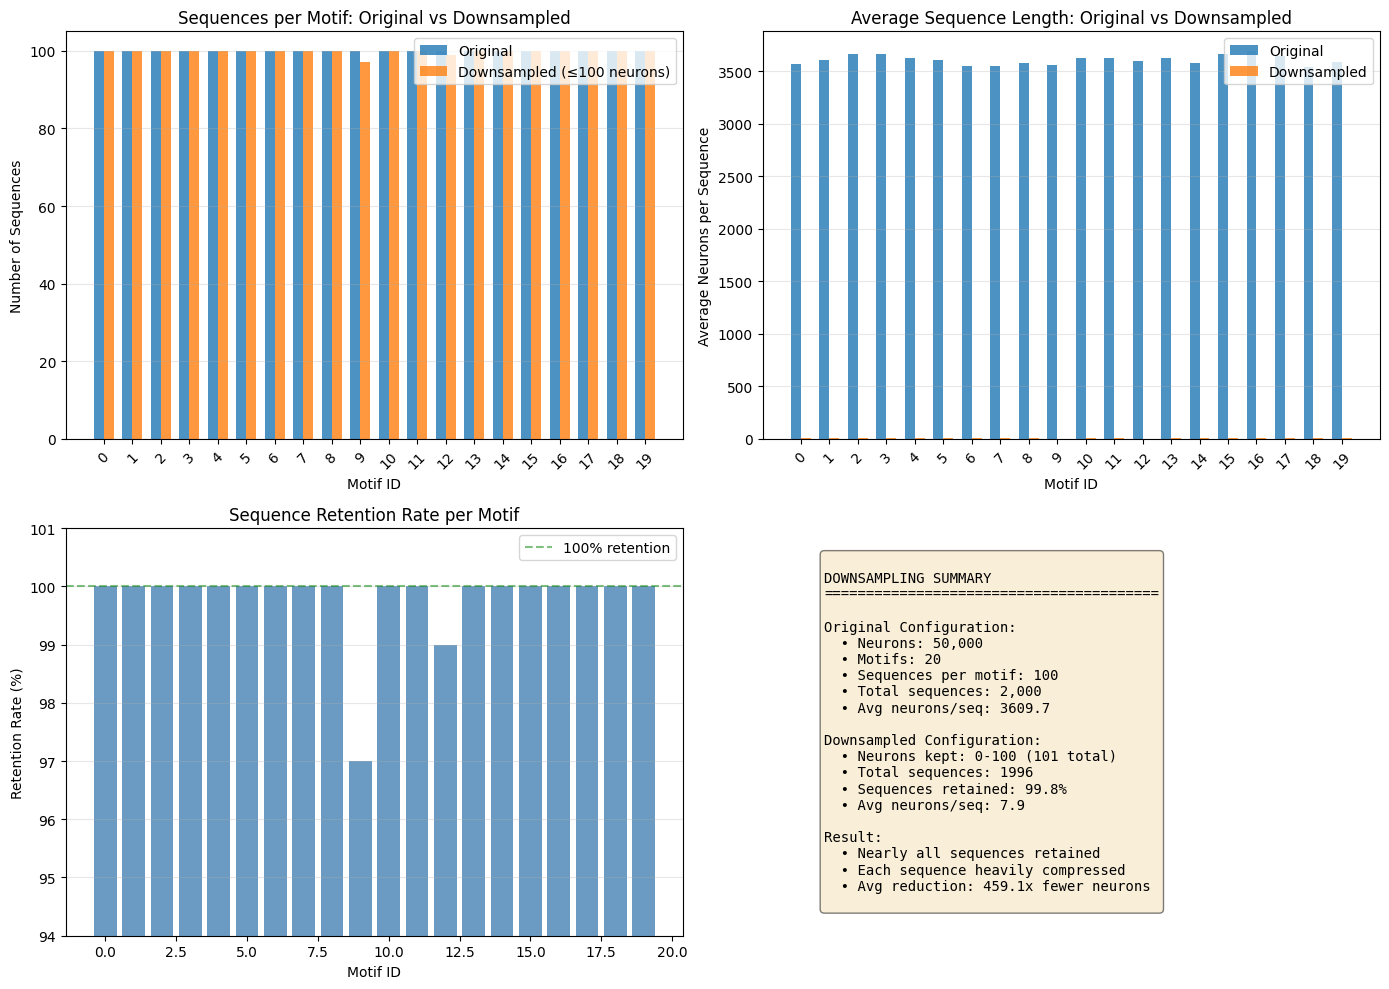

In [8]:
# Visualize the downsampling effect
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Sequences per motif
motif_ids = sorted(sequences.keys())
orig_counts = [len(sequences[m]) for m in motif_ids]
down_counts = [len(seqs_downsampled[m]) for m in motif_ids]

ax = axes[0, 0]
x = np.arange(len(motif_ids))
width = 0.35
ax.bar(x - width/2, orig_counts, width, label='Original', alpha=0.8)
ax.bar(x + width/2, down_counts, width, label='Downsampled (≤100 neurons)', alpha=0.8)
ax.set_xlabel('Motif ID')
ax.set_ylabel('Number of Sequences')
ax.set_title('Sequences per Motif: Original vs Downsampled')
ax.set_xticks(x)
ax.set_xticklabels(motif_ids, rotation=45)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 2. Average neurons per sequence
avg_orig_per_motif = [np.mean([len(s) for s in sequences[m]]) for m in motif_ids]
avg_down_per_motif = [np.mean([len(s) for s in seqs_downsampled[m]]) if seqs_downsampled[m] else 0 
                       for m in motif_ids]

ax = axes[0, 1]
ax.bar(x - width/2, avg_orig_per_motif, width, label='Original', alpha=0.8)
ax.bar(x + width/2, avg_down_per_motif, width, label='Downsampled', alpha=0.8)
ax.set_xlabel('Motif ID')
ax.set_ylabel('Average Neurons per Sequence')
ax.set_title('Average Sequence Length: Original vs Downsampled')
ax.set_xticks(x)
ax.set_xticklabels(motif_ids, rotation=45)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 3. Retention rate per motif
retention_rates = [100 * down_counts[i] / orig_counts[i] for i in range(len(motif_ids))]

ax = axes[1, 0]
ax.bar(motif_ids, retention_rates, color='steelblue', alpha=0.8)
ax.axhline(y=100, color='green', linestyle='--', alpha=0.5, label='100% retention')
ax.set_xlabel('Motif ID')
ax.set_ylabel('Retention Rate (%)')
ax.set_title('Sequence Retention Rate per Motif')
ax.set_ylim([94, 101])
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 4. Summary statistics
ax = axes[1, 1]
ax.axis('off')
summary_text = f"""
DOWNSAMPLING SUMMARY
{'='*40}

Original Configuration:
  • Neurons: 50,000
  • Motifs: 20
  • Sequences per motif: 100
  • Total sequences: 2,000
  • Avg neurons/seq: {np.mean(avg_orig_per_motif):.1f}

Downsampled Configuration:
  • Neurons kept: 0-100 (101 total)
  • Total sequences: {total_down}
  • Sequences retained: {total_down/total_orig*100:.1f}%
  • Avg neurons/seq: {np.mean(avg_down_per_motif):.1f}

Result:
  • Nearly all sequences retained
  • Each sequence heavily compressed
  • Avg reduction: {np.mean(avg_orig_per_motif)/np.mean(avg_down_per_motif):.1f}x fewer neurons
"""
ax.text(0.1, 0.5, summary_text, fontfamily='monospace', fontsize=10, 
        verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [5]:
# Test with min_length filter
seqs_downsampled_filtered, spk_times_downsampled_filt, volume_downsampled_filt = downsample_sequences(
    sequences, spk_times, volume, n_neurons_keep=100, min_length=5
)

In [10]:
# Summary of filtering
print("\n" + "="*60)
print("SUMMARY: Effect of min_length=5 Filter")
print("="*60)
print(f"Total sequences (n_neurons_keep=100, no filter): {total_orig_filt}")
print(f"Total sequences (n_neurons_keep=100, min_length=5): {total_filt}")
print(f"Sequences removed: {total_orig_filt - total_filt}")
print(f"Retention rate: {total_filt/total_orig_filt*100:.1f}%")
print("="*60)


SUMMARY: Effect of min_length=5 Filter
Total sequences (n_neurons_keep=100, no filter): 1996
Total sequences (n_neurons_keep=100, min_length=5): 1766
Sequences removed: 230
Retention rate: 88.5%


Testing different n_neurons_keep values (with min_length=5)...

n_neurons_keep=   10 → 0 motifs retained (with min_length=5)
n_neurons_keep=   20 → 5 motifs retained (with min_length=5)
n_neurons_keep=   50 → 19 motifs retained (with min_length=5)
n_neurons_keep=  100 → 20 motifs retained (with min_length=5)
n_neurons_keep=  200 → 20 motifs retained (with min_length=5)
n_neurons_keep=  500 → 20 motifs retained (with min_length=5)
n_neurons_keep= 1000 → 20 motifs retained (with min_length=5)
n_neurons_keep= 2000 → 20 motifs retained (with min_length=5)
n_neurons_keep= 5000 → 20 motifs retained (with min_length=5)


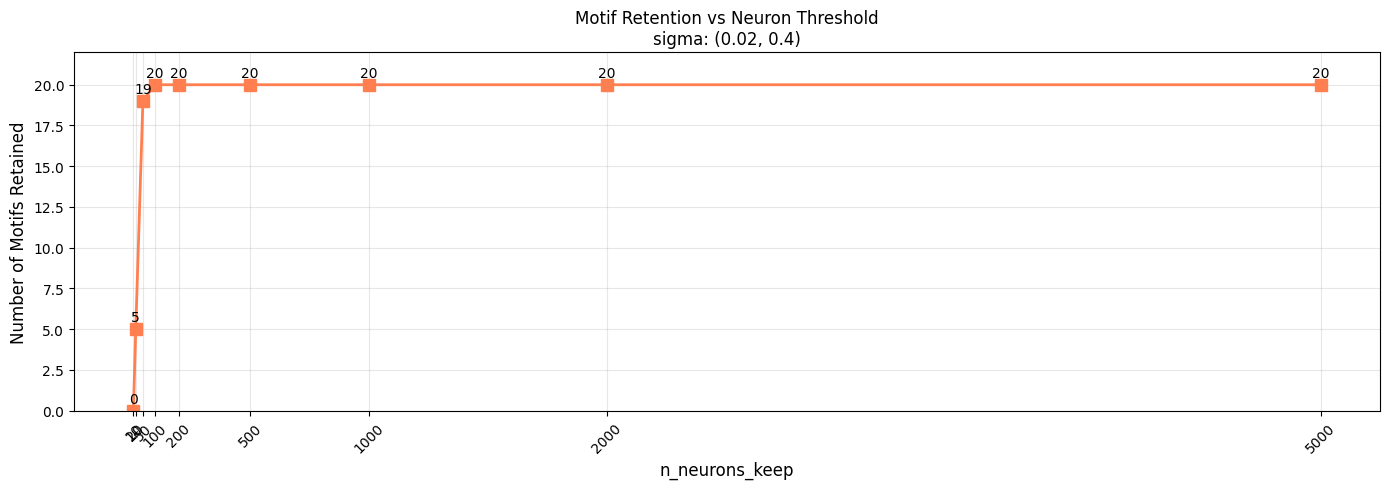

In [6]:
# Test different n_neurons_keep values and count motifs (with min_length=5 filter)
n_neurons_keep_values = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000]
motif_counts_filtered = []

print("Testing different n_neurons_keep values (with min_length=5)...\n")
for n_keep in n_neurons_keep_values:
    seqs_down, _, _ = downsample_sequences(sequences, spk_times, volume, n_keep, min_length=5)
    
    # Count motifs that have at least one sequence
    motifs_with_seqs = sum(1 for motif_id, seqs in seqs_down.items() if len(seqs) > 0)
    motif_counts_filtered.append(motifs_with_seqs)
    
    print(f"n_neurons_keep={n_keep:5d} → {motifs_with_seqs} motifs retained (with min_length=5)")

# Plot
fig, ax = plt.subplots(figsize=(14, 5))

# Plot 2: With min_length=5 filter
ax.plot(n_neurons_keep_values, motif_counts_filtered, marker='s', linewidth=2, 
         markersize=8, color='coral', label='min_length=5')
ax.set_xlabel('n_neurons_keep', fontsize=12)
ax.set_ylabel('Number of Motifs Retained', fontsize=12)
ax.set_title(f'Motif Retention vs Neuron Threshold\nsigma: {params["sigma_range"]}', fontsize=12,)
ax.grid(True, alpha=0.3)
ax.set_xticks(n_neurons_keep_values)
ax.set_xticklabels(n_neurons_keep_values, rotation=45)
ax.set_ylim([0, 22])

# Add value labels on both plots
for x, y in zip(n_neurons_keep_values, motif_counts_filtered):
    ax.text(x, y + 0.3, str(int(y)), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


In [13]:
%reload_ext autoreload

In [7]:
# Convert dict to flat list for allmot
seqs_flat = []
for motif_id in sorted(seqs_downsampled_filtered.keys()):
    seqs_flat.extend(seqs_downsampled_filtered[motif_id])

print(f"Total sequences (flat): {len(seqs_flat)}")
print(f"Expected from filtered: {sum(len(seqs) for seqs in seqs_downsampled_filtered.values())}")

# Now run allmot
rep_index_down, nsig_down, pval_down, bmat_down, zmat_down, corrmat_down = rs.allmot(seqs_flat, nrm)
print("Done!")

Total sequences (flat): 1766
Expected from filtered: 1766
Done!


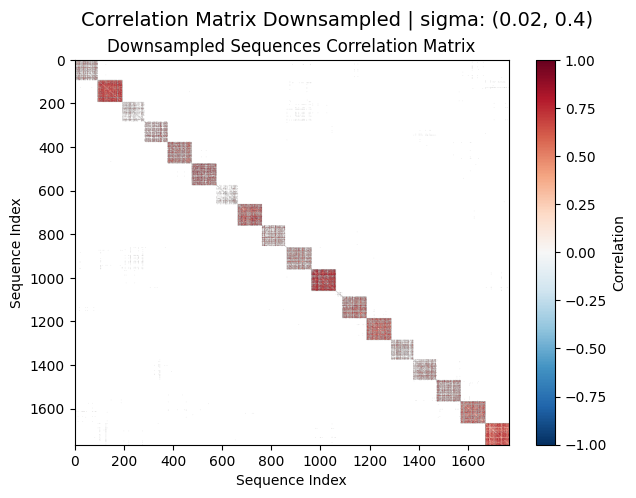

In [9]:
plt.figure(figsize=(7, 5))
plt.imshow(corrmat_down, aspect='auto', cmap='RdBu_r')
plt.colorbar(label='Correlation')
plt.title('Downsampled Sequences Correlation Matrix')
plt.xlabel('Sequence Index')
plt.ylabel('Sequence Index')    
plt.suptitle(f'Correlation Matrix Downsampled | sigma: {params["sigma_range"]}', fontsize=14)
plt.show()

In [2]:
# PARAMETERS
params = {
    "n_neurons": 50000,
    "n_motifs": 20,
    "n_bins": 100,
    "n_sequences": 100,
    "sigma_range": (1,1),    # increasing range makes sequences less similar
    "vol_param": (0.07, 0.9),     # beta distribution:  0.07, 0.9
                                  # a inactive (lower -> more neurons inactive, if high longer seqs, mean len shifts)
                                  # b active (lower -> more neurons active, if <1, skewed to 1, if lower longer seqs, mean len shifts)
    "corr_mu": False,
    "rho_mu": 0.0,
    "corr_sigma": False,
    "rho_sig": 0.0,
    "corr_volume": False,
    "rho_vol": 0.0,
    "shuffle_order": False,       # shuffle order of sequences

}

In [3]:
seqs, seqs_labels, spk_times, sequences, true_templates, mu, sigma, volume, densities, cdfs = simulate_sequences(**params, random_state=2, plot=False, batch_size=5000)

Processed batch: neurons 0-5000/50000
Processed batch: neurons 5000-10000/50000
Processed batch: neurons 10000-15000/50000
Processed batch: neurons 15000-20000/50000
Processed batch: neurons 20000-25000/50000
Processed batch: neurons 25000-30000/50000
Processed batch: neurons 30000-35000/50000
Processed batch: neurons 35000-40000/50000
Processed batch: neurons 40000-45000/50000
Processed batch: neurons 45000-50000/50000
Generated sequences for motif 0/20
Generated sequences for motif 1/20
Generated sequences for motif 2/20
Generated sequences for motif 3/20
Generated sequences for motif 4/20
Generated sequences for motif 5/20
Generated sequences for motif 6/20
Generated sequences for motif 7/20
Generated sequences for motif 8/20
Generated sequences for motif 9/20
Generated sequences for motif 10/20
Generated sequences for motif 11/20
Generated sequences for motif 12/20
Generated sequences for motif 13/20
Generated sequences for motif 14/20
Generated sequences for motif 15/20
Generated 

Testing different n_neurons_keep values (with min_length=5)...

n_neurons_keep=   10 → 0 motifs retained (with min_length=5)
n_neurons_keep=   20 → 5 motifs retained (with min_length=5)
n_neurons_keep=   50 → 19 motifs retained (with min_length=5)
n_neurons_keep=  100 → 20 motifs retained (with min_length=5)
n_neurons_keep=  200 → 20 motifs retained (with min_length=5)
n_neurons_keep=  500 → 20 motifs retained (with min_length=5)
n_neurons_keep= 1000 → 20 motifs retained (with min_length=5)
n_neurons_keep= 2000 → 20 motifs retained (with min_length=5)
n_neurons_keep= 5000 → 20 motifs retained (with min_length=5)


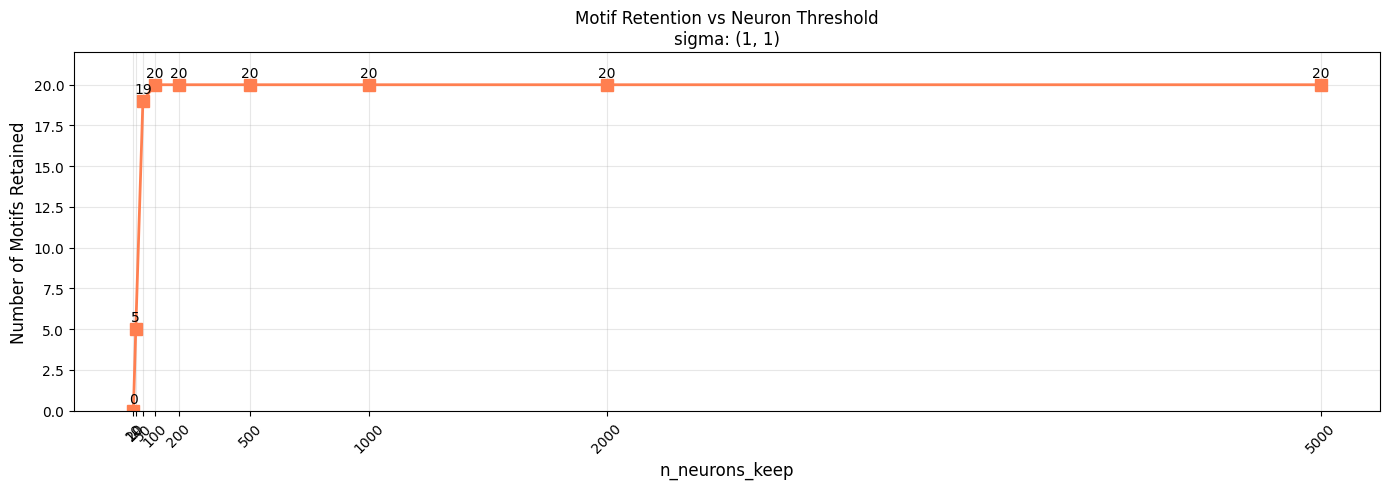

In [16]:
# Test different n_neurons_keep values and count motifs (with min_length=5 filter)
n_neurons_keep_values = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000]
motif_counts_filtered = []

print("Testing different n_neurons_keep values (with min_length=5)...\n")
for n_keep in n_neurons_keep_values:
    seqs_down, _, _ = downsample_sequences(sequences, spk_times, volume, n_keep, min_length=5)
    
    # Count motifs that have at least one sequence
    motifs_with_seqs = sum(1 for motif_id, seqs in seqs_down.items() if len(seqs) > 0)
    motif_counts_filtered.append(motifs_with_seqs)
    
    print(f"n_neurons_keep={n_keep:5d} → {motifs_with_seqs} motifs retained (with min_length=5)")

# Plot
fig, ax = plt.subplots(figsize=(14, 5))

# Plot 2: With min_length=5 filter
ax.plot(n_neurons_keep_values, motif_counts_filtered, marker='s', linewidth=2, 
         markersize=8, color='coral', label='min_length=5')
ax.set_xlabel('n_neurons_keep', fontsize=12)
ax.set_ylabel('Number of Motifs Retained', fontsize=12)
ax.set_title(f'Motif Retention vs Neuron Threshold\nsigma: {params["sigma_range"]}', fontsize=12,)
ax.grid(True, alpha=0.3)
ax.set_xticks(n_neurons_keep_values)
ax.set_xticklabels(n_neurons_keep_values, rotation=45)
ax.set_ylim([0, 22])

# Add value labels on both plots
for x, y in zip(n_neurons_keep_values, motif_counts_filtered):
    ax.text(x, y + 0.3, str(int(y)), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
seqs_downsampled_filtered, spk_times_downsampled_filtered, volume_downsampled_filtered = downsample_sequences(sequences, spk_times, volume, 100, min_length=5)

seqs_flat = []
for motif_id in sorted(seqs_downsampled_filtered.keys()):
    seqs_flat.extend(seqs_downsampled_filtered[motif_id])

rep_index_down, nsig_down, pval_down, bmat_down, zmat_down, corrmat_down = rs.allmot(seqs_flat, nrm)


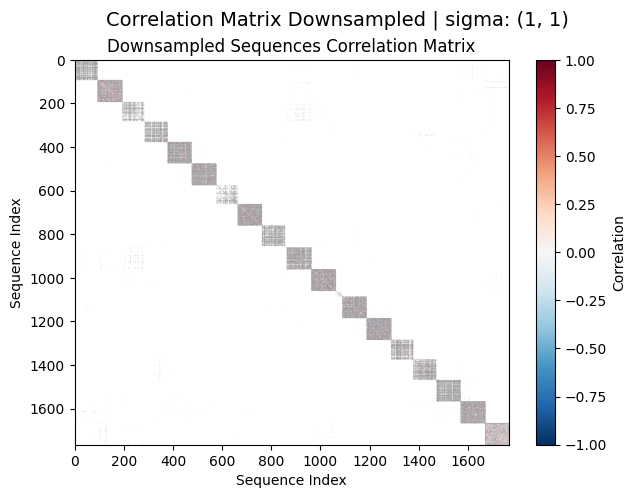

In [15]:
plt.figure(figsize=(7, 5))
plt.imshow(corrmat_down, aspect='auto', cmap='RdBu_r')
plt.colorbar(label='Correlation')
plt.title('Downsampled Sequences Correlation Matrix')
plt.xlabel('Sequence Index')
plt.ylabel('Sequence Index')    
plt.suptitle(f'Correlation Matrix Downsampled | sigma: {params["sigma_range"]}', fontsize=14)
plt.show()